   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


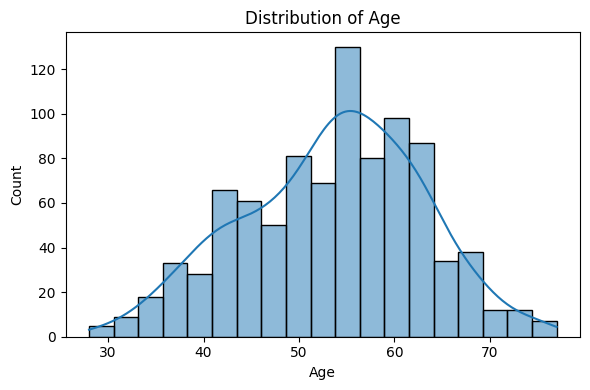

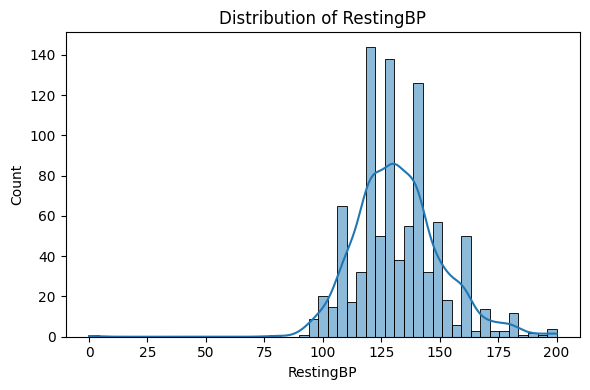

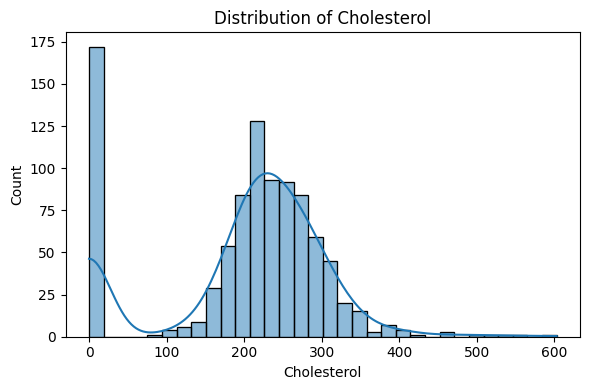

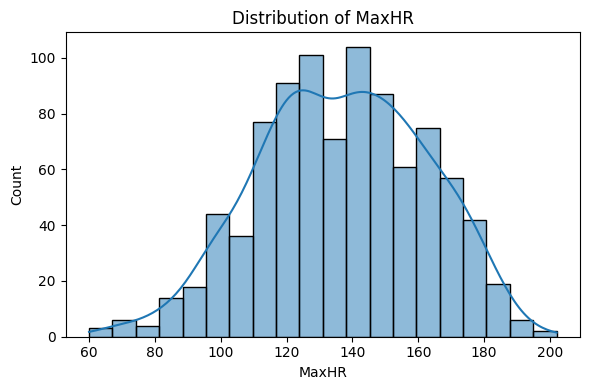

Age               0
is_female         0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
   Age  is_female  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0   40          0      140.0        289.0          0    172               0   
1   49          1      160.0        180.0          0    156               0   
2   37          0      130.0        283.0          0     98               0   
3   48          1      138.0        214.0          0    108               1   
4   54          0      150.0        195.0          0    122               0   
5   39          0      120.0        339.0          0    170               0   
6   45          1      130.0        237.0          0    170               0   
7   54          0      110.0        208.0          0    142               0   
8   37          0      140.0        

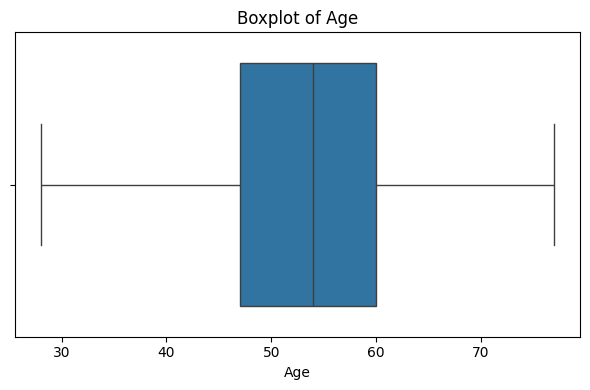

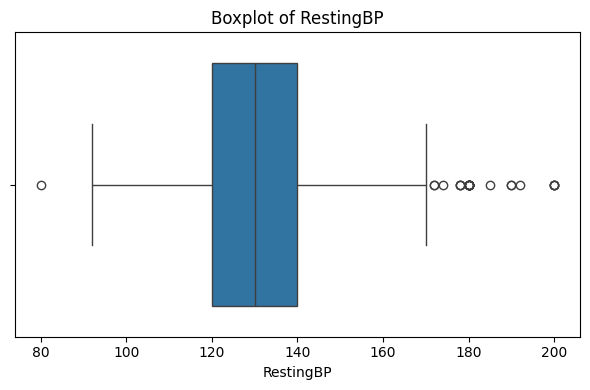

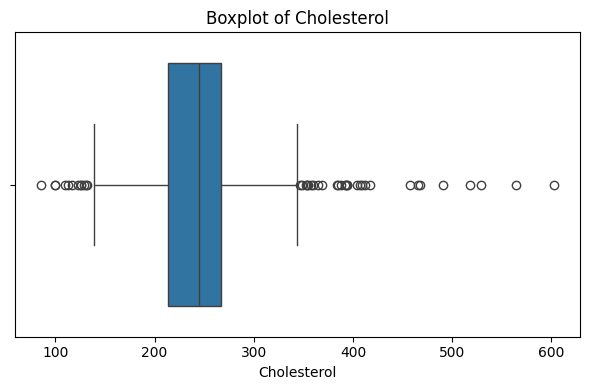

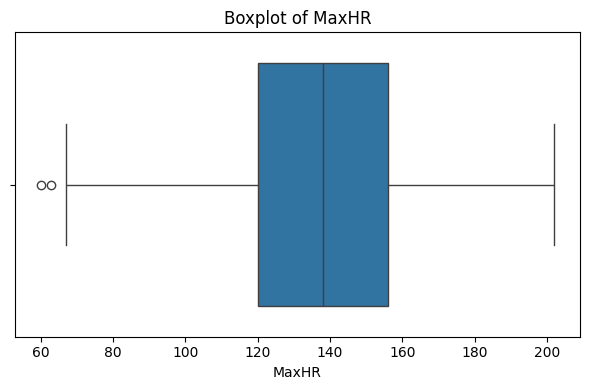

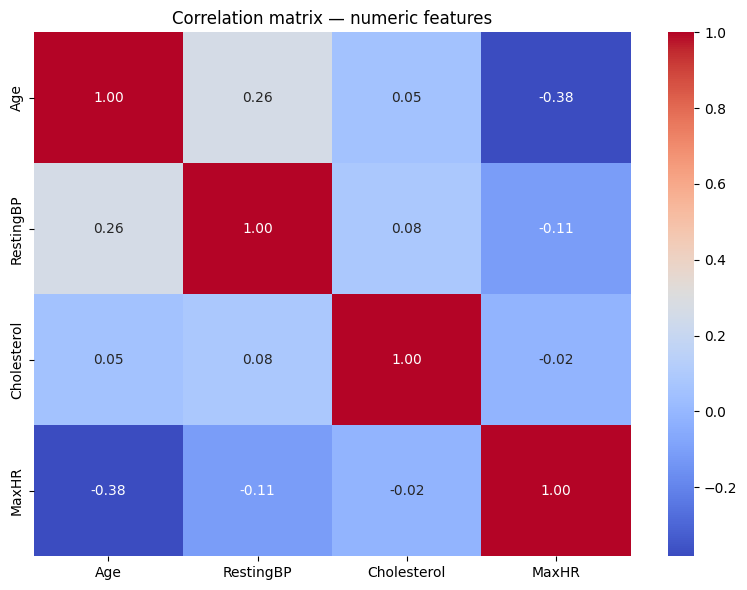


Final dataframe head:
         Age  is_female  RestingBP  Cholesterol  FastingBS     MaxHR  \
0 -1.433140          0   0.414853     0.832513          0  1.382928   
1 -0.478484          1   1.527192    -1.212938          0  0.754157   
2 -1.751359          0  -0.141317     0.719919          0 -1.525138   
3 -0.584556          1   0.303619    -0.574908          0 -1.132156   
4  0.051881          0   0.971022    -0.931454          0 -0.581981   
5 -1.539213          0  -0.697486     1.770793          0  1.304332   
6 -0.902775          1  -0.141317    -0.143299          0  1.304332   
7  0.051881          0  -1.253656    -0.687501          0  0.203982   
8 -1.751359          0   0.414853    -0.706267          0 -0.267596   
9 -0.584556          1  -0.697486     0.738685          0 -0.660578   

   ExerciseAngina  Oldpeak  HeartDisease  ST_Slope_Down  ST_Slope_Flat  \
0               0      0.0             0              0              0   
1               0      1.0             1      

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv("heart.csv")
print(df.head())
print(df.columns)

# ─────────────────────────────────────────
# 2. INITIAL DISTRIBUTION PLOTS (FIXED: added title + plt.show())
# ─────────────────────────────────────────
numeric_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

for i in numeric_col:
    plt.figure(figsize=(6, 4))
    sns.histplot(x=df[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────
# 3. ENCODE BINARY COLUMNS
# ─────────────────────────────────────────
df['Sex'] = df['Sex'].map({"M": 0, "F": 1})
df.rename(columns={"Sex": "is_female"}, inplace=True)

df['ExerciseAngina'] = df['ExerciseAngina'].map({"Y": 1, "N": 0})

# ─────────────────────────────────────────
# 4. HANDLE MISSING / ZERO VALUES
# ─────────────────────────────────────────
print(df.isnull().sum())

# Replace 0s in Cholesterol with mean of non-zero values
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean().round(2)
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)

# Replace 0s in RestingBP with mean of non-zero values
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean().round(2)
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)

# ─────────────────────────────────────────
# 5. ONE-HOT ENCODING
# ─────────────────────────────────────────
df = pd.get_dummies(data=df, columns=['ST_Slope', 'RestingECG', 'ChestPainType'])

# FIXED: Only cast bool dummy columns to int, not entire dataframe
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.head(10))

# ─────────────────────────────────────────
# 6. STATISTICAL TESTS (BEFORE SCALING)
# Run tests on unscaled data for valid results
# ─────────────────────────────────────────
selected_features = [
    'Age', 'is_female', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
    'ExerciseAngina', 'Oldpeak', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up',
    'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
    'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA'
]

# --- Pearson Correlation (for all features vs target) ---
correlations = {
    feature: pearsonr(df[feature], df['HeartDisease'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(
    list(correlations.items()), columns=['Feature', 'Pearson Correlation']
)
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)
print("\nPearson Correlation:\n", correlation_df)

# --- Chi-Square Test (FIXED: only categorical/binary features) ---
cat_features = [
    'is_female', 'FastingBS', 'ExerciseAngina',
    'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up',
    'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
    'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA'
]
# Note: Age, RestingBP, Cholesterol, MaxHR are continuous
# → use Pearson correlation results for those (already done above)

alpha = 0.05
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df[col], df['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = (
        'Reject Null (Keep Feature)' if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
print("\nChi-Square Results:\n", chi2_df)

# ─────────────────────────────────────────
# 7. VISUALISE NUMERIC COLUMNS (FIXED: boxplots + one correlation heatmap)
# ─────────────────────────────────────────

# Option A: Boxplot per numeric column
for i in numeric_col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.tight_layout()
    plt.show()

# Option B: Correlation heatmap (2D — correct usage of heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_col].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 8. SCALING (AFTER statistical tests)
# ─────────────────────────────────────────
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

print("\nFinal dataframe head:\n", df.head(10))
print("\nFinal columns:\n", df.columns.tolist())